# Week 2 — Friday Hands-on
## Research-style laboratory: Polarimetry, representation geometry, and mini-project launch

**Course:** Machine Learning and Artificial Intelligence for Modern Astrophysics  
**Format:** research-style Jupyter laboratory  
**Total duration:** approximately 100–120 minutes (two 50–60 minute slots)

### Today's change of mode

Monday:
$$
\boxed{\text{Follow the workflow}}
$$

Wednesday:
$$
\boxed{\text{Compare representations}}
$$

Friday:
$$
\boxed{\text{Make and defend scientific decisions}}
$$

The instructor should do less live coding today. Students should increasingly predict, choose,
intervene, interpret, and justify.

---

# Central questions

### Slot 1 — Polarimetry

> **How can the geometry of a physical observable determine whether a machine-learning representation
> is sensible?**

### Slot 2 — Mini-project studio

> **Can you formulate a small astrophysical ML study whose scientific claim is testable, validated,
> and reproducible?**

---

# Suggested timing

| Approx. time | Activity |
|---:|---|
| 0–10 min | Polarimetry physics and geometry |
| 10–20 min | Generate/audit synthetic observations |
| 20–30 min | Physical baseline |
| 30–45 min | Naïve vs geometry-aware ML |
| 45–55 min | Wrap-around and low-S/N diagnostics |
| **break / transition** | |
| 55–65 min | From exercise to research question |
| 65–80 min | Groups choose project and complete research canvas |
| 80–95 min | Design minimum viable experiment |
| 95–108 min | 2–3 minute group pitches |
| 108–118 min | Peer review + revision |
| 118–120 min | Course synthesis |

Use the pattern

$$
\boxed{\text{Predict}\rightarrow\text{Run}\rightarrow\text{Explain}\rightarrow\text{Decide}}
$$

The final step, **Decide**, is what makes this a research-style laboratory.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

SEED = 42
np.random.seed(SEED)

def orientation_error_deg(true_deg, pred_deg):
    """Absolute smallest error for a 180-degree-periodic orientation."""
    delta = np.deg2rad(pred_deg - true_deg)
    wrapped = 0.5 * np.arctan2(np.sin(2 * delta), np.cos(2 * delta))
    return np.abs(np.rad2deg(wrapped))

def circular_summary(true_deg, pred_deg):
    err = orientation_error_deg(true_deg, pred_deg)
    return {
        "circular_MAE_deg": np.mean(err),
        "median_error_deg": np.median(err),
        "p90_error_deg": np.percentile(err, 90),
    }


# Slot 1 — Polarimetry as a representation-geometry problem

For linear polarimetry,

$$
q=\frac{Q}{I}~,
\qquad
u=\frac{U}{I}~,
$$

and

$$
p=\sqrt{q^2+u^2}~,
\qquad
\chi=\frac{1}{2}\operatorname{atan2}(u,q)~.
$$

The factor of $1/2$ is essential because linear polarization is an **orientation**, not an arrow.

Therefore

$$
\chi \equiv \chi+180^\circ~.
$$

A position angle of $179^\circ$ is physically close to $1^\circ$, even though ordinary Euclidean
subtraction says they differ by $178^\circ$.

That is a machine-learning geometry problem.

---

## Scientific task

We simulate multi-band $BVR$ polarimetry of unresolved circumstellar disks.

The target is the intrinsic disk polarization position angle

$$
\psi \in [0^\circ,180^\circ)~.
$$

Each source also has:

- disk inclination $i$;
- wavelength-dependent intrinsic polarization amplitude;
- weak interstellar-polarization contamination;
- measurement noise.

We will compare four approaches:

1. **Physical baseline:** use the observed $V$-band angle directly;
2. **Naïve ML:** use $(p,\chi)$ and regress $\psi$ as an ordinary scalar;
3. **Stokes-aware ML:** use $(q,u)$ and predict $(\cos2\psi,\sin2\psi)$;
4. **Angle-safe ML:** use $(p,\cos2\chi,\sin2\chi)$ and predict
   $(\cos2\psi,\sin2\psi)$.

The goal is not to prove that one coordinate system is universally superior.

The goal is to ask:

> **Does the representation respect the topology and symmetry of the physical observable?**


## 1. Generate a controlled multi-band polarimetry dataset

The synthetic model is intentionally simple.

For the intrinsic disk polarization,

$$
p_{\rm disk}(\lambda)
\propto
\sin^2 i~.
$$

The intrinsic Stokes parameters are

$$
q_{\rm disk}=p_{\rm disk}\cos 2\psi~,
\qquad
u_{\rm disk}=p_{\rm disk}\sin 2\psi~.
$$

A weaker interstellar-polarization vector is added, with a different wavelength dependence, followed by
Gaussian measurement noise.

This is a **teaching model**, not a complete radiative-transfer model of Be-star polarization.


In [2]:
def make_polarimetry_dataset(n=3000, seed=42, noise_sigma=0.035, isp_scale=1.0):
    """
    Synthetic BVR linear polarimetry in percent units.

    Returns a table containing observed q,u,p,chi in each band and latent physical parameters.
    """
    rng = np.random.default_rng(seed)
    bands = ["B", "V", "R"]
    disk_lambda_factor = {"B": 1.08, "V": 1.00, "R": 0.93}
    isp_lambda_factor = {"B": 0.88, "V": 1.00, "R": 0.94}

    rows = []
    for i in range(n):
        psi = rng.uniform(0.0, 180.0)              # intrinsic disk polarization PA
        inclination = np.rad2deg(np.arccos(rng.uniform(0.0, 1.0)))
        p0 = rng.uniform(0.45, 1.15)               # percent
        p_disk_base = p0 * np.sin(np.deg2rad(inclination))**2

        p_isp = isp_scale * rng.uniform(0.0, 0.22) # weak nuisance component, percent
        psi_isp = rng.uniform(0.0, 180.0)

        row = {
            "object_id": f"POL_{i:05d}",
            "psi_true_deg": psi,
            "inclination_deg": inclination,
            "p_disk_base": p_disk_base,
            "p_isp": p_isp,
            "psi_isp_deg": psi_isp,
        }

        for band in bands:
            p_disk = p_disk_base * disk_lambda_factor[band]
            q_disk = p_disk * np.cos(np.deg2rad(2 * psi))
            u_disk = p_disk * np.sin(np.deg2rad(2 * psi))

            p_isp_band = p_isp * isp_lambda_factor[band]
            q_isp = p_isp_band * np.cos(np.deg2rad(2 * psi_isp))
            u_isp = p_isp_band * np.sin(np.deg2rad(2 * psi_isp))

            q = q_disk + q_isp + rng.normal(0.0, noise_sigma)
            u = u_disk + u_isp + rng.normal(0.0, noise_sigma)

            p = np.sqrt(q*q + u*u)
            chi = (0.5 * np.rad2deg(np.arctan2(u, q))) % 180.0

            row[f"q_{band}"] = q
            row[f"u_{band}"] = u
            row[f"p_{band}"] = p
            row[f"chi_{band}"] = chi
            row[f"snr_p_{band}"] = p / noise_sigma

        rows.append(row)

    return pd.DataFrame(rows)

pol = make_polarimetry_dataset()
pol.head()


,object_id,psi_true_deg,inclination_deg,p_disk_base,p_isp,psi_isp_deg,q_B,u_B,p_B,chi_B,snr_p_B,q_V,u_V,p_V,chi_V,snr_p_V,q_R,u_R,p_R,chi_R,snr_p_R
0,POL_00000,139.312089,63.967657,0.848577,0.153421,16.951923,0.203905,-0.826318,0.851104,141.930789,24.317266,0.243513,-0.753992,0.792340,143.949329,22.638296,0.208178,-0.669031,0.700672,143.642112,20.019194
1,POL_00001,166.817698,49.919361,0.600620,0.097551,40.902970,0.606340,-0.236655,0.650887,169.339653,18.596777,0.582797,-0.171917,0.607624,171.782353,17.360691,0.507076,-0.181124,0.538454,170.171803,15.384386
2,POL_00002,174.725644,26.731896,0.201296,0.042821,84.009781,0.189655,-0.017532,0.190464,177.359232,5.441824,0.171085,0.046995,0.177422,7.679748,5.069209,0.130443,-0.043845,0.137614,170.710575,3.931838
3,POL_00003,66.682747,61.994533,0.454170,0.028583,85.626887,-0.390521,0.383186,0.547118,67.771603,15.631953,-0.314092,0.353533,0.472905,65.809558,13.511585,-0.339874,0.319275,0.466316,68.394979,13.323328
4,POL_00004,69.746108,73.242112,0.850620,0.030746,35.983476,-0.687740,0.632570,0.934415,68.696389,26.697563,-0.615129,0.530756,0.812457,69.605568,23.213050,-0.603712,0.524863,0.799968,69.498252,22.856234


## 2. Audit the polarimetric geometry

Before fitting anything:

- plot the $q-u$ plane;
- inspect the distribution of $\chi$;
- identify sources near the coordinate boundary $0^\circ/180^\circ$;
- inspect how polarization amplitude changes with inclination.

### Predict → Run → Explain

> A star with true $\psi=179^\circ$ and another with $\psi=1^\circ$ have almost the same
> polarization orientation. Which representation makes that closeness obvious?


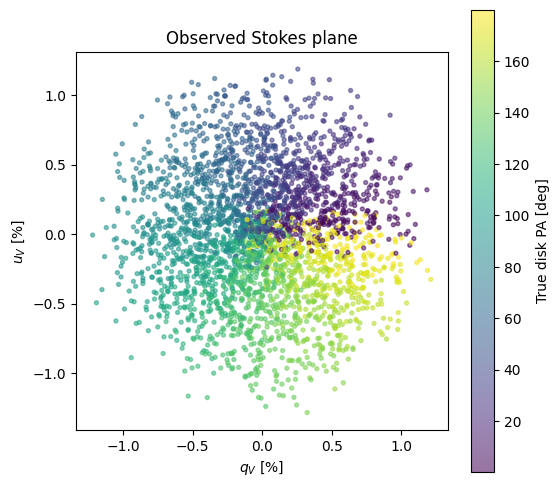

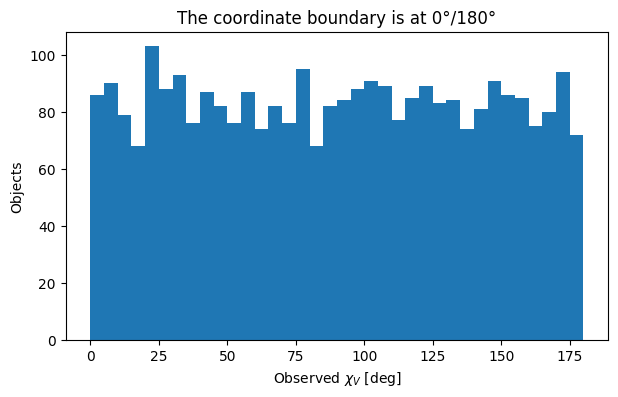

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(pol["q_V"], pol["u_V"], c=pol["psi_true_deg"], s=8, alpha=0.55)
ax.set_xlabel(r"$q_V$ [%]")
ax.set_ylabel(r"$u_V$ [%]")
ax.set_title("Observed Stokes plane")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("True disk PA [deg]")
ax.set_aspect("equal", adjustable="box")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pol["chi_V"], bins=36)
ax.set_xlabel(r"Observed $\chi_V$ [deg]")
ax.set_ylabel("Objects")
ax.set_title("The coordinate boundary is at 0°/180°")
plt.show()


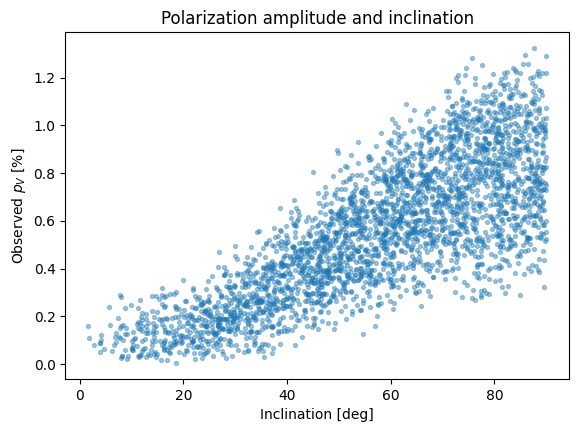

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(pol["inclination_deg"], pol["p_V"], s=8, alpha=0.4)
ax.set_xlabel("Inclination [deg]")
ax.set_ylabel(r"Observed $p_V$ [%]")
ax.set_title("Polarization amplitude and inclination")
plt.show()


In [5]:
# Stratify by true angle bins so all splits contain wrap-region examples.
angle_bin = pd.cut(
    pol["psi_true_deg"],
    bins=np.linspace(0, 180, 13),
    labels=False,
    include_lowest=True,
)

train_idx, temp_idx = train_test_split(
    np.arange(len(pol)),
    test_size=0.40,
    stratify=angle_bin,
    random_state=SEED,
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=angle_bin.iloc[temp_idx],
    random_state=SEED,
)

print("split sizes:", len(train_idx), len(val_idx), len(test_idx))


split sizes: 1800 600 600


## 3. Establish a physical baseline before ML

A sensible baseline is simply

$$
\widehat\psi_{\rm base}=\chi_V~.
$$

This already contains real physical information.

A machine-learning model should therefore not be compared only with a random predictor.

It should be compared with the **obvious physics-informed estimator**.

### Circular/orientation error

Ordinary absolute error is wrong for a $180^\circ$-periodic orientation.

Define

$$
\Delta\psi=
\frac12
\operatorname{atan2}
\left[
\sin 2(\widehat\psi-\psi),
\cos 2(\widehat\psi-\psi)
\right]~.
$$

We report

$$
|\Delta\psi|~,
$$

in degrees.


In [6]:
y_true = pol["psi_true_deg"].to_numpy()

baseline_pred = pol.loc[test_idx, "chi_V"].to_numpy()
baseline_summary = circular_summary(y_true[test_idx], baseline_pred)

pd.Series(baseline_summary, name="V-band angle baseline")


circular_MAE_deg     6.603389
median_error_deg     3.282361
p90_error_deg       14.225240
Name: V-band angle baseline, dtype: float64

## 4. Naïve ML representation

Construct, for each band,

$$
(p_B,~\chi_B,~p_V,~\chi_V,~p_R,~\chi_R)~.
$$

Then train an ordinary regressor to predict the scalar target $\psi$.

This looks reasonable until the representation encounters the wrap:

$$
179^\circ \approx 1^\circ
\quad\text{physically}~,
$$

but not numerically.

### Predict

> Where do you expect the naïve model to make its largest errors?


In [7]:
naive_cols = [
    "p_B", "chi_B",
    "p_V", "chi_V",
    "p_R", "chi_R",
]

rf_naive = RandomForestRegressor(
    n_estimators=350,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)
rf_naive.fit(pol.loc[train_idx, naive_cols], y_true[train_idx])
pred_naive = rf_naive.predict(pol.loc[test_idx, naive_cols]) % 180.0

pd.Series(circular_summary(y_true[test_idx], pred_naive), name="naive p,chi -> scalar angle")


circular_MAE_deg    10.138265
median_error_deg     3.444349
p90_error_deg       29.007920
Name: naive p,chi -> scalar angle, dtype: float64

## 5. Geometry-aware target and representations

Instead of predicting $\psi$ directly, predict

$$
\mathbf y_{\rm circ}=
(\cos 2\psi,\sin 2\psi)~.
$$

Recover the angle using

$$
\widehat\psi=
\frac12
\operatorname{atan2}
(\widehat s,\widehat c)
\pmod{180^\circ}~.
$$

We compare two input representations.

### A. Raw Stokes representation

$$
(q_B,~u_B,~q_V,~u_V,~q_R,~u_R)~.
$$

### B. Angle-safe polar representation

For each band,

$$
(p,~\cos2\chi,~\sin2\chi)~.
$$

The second representation makes amplitude and orientation explicit while retaining periodicity.


In [8]:
def circular_target(angle_deg):
    a = np.deg2rad(angle_deg)
    return np.column_stack([np.cos(2*a), np.sin(2*a)])

def decode_circular_target(cs):
    c = cs[:, 0]
    s = cs[:, 1]
    return (0.5 * np.rad2deg(np.arctan2(s, c))) % 180.0

Ycirc = circular_target(y_true)

stokes_cols = ["q_B", "u_B", "q_V", "u_V", "q_R", "u_R"]

rf_stokes = RandomForestRegressor(
    n_estimators=350,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)
rf_stokes.fit(pol.loc[train_idx, stokes_cols], Ycirc[train_idx])
pred_stokes = decode_circular_target(rf_stokes.predict(pol.loc[test_idx, stokes_cols]))

pd.Series(circular_summary(y_true[test_idx], pred_stokes), name="q,u -> circular target")


circular_MAE_deg     5.734595
median_error_deg     2.843515
p90_error_deg       11.574713
Name: q,u -> circular target, dtype: float64

In [9]:
def add_angle_safe_features(df):
    out = df.copy()
    for band in ["B", "V", "R"]:
        chi_rad = np.deg2rad(out[f"chi_{band}"].to_numpy())
        out[f"cos2chi_{band}"] = np.cos(2 * chi_rad)
        out[f"sin2chi_{band}"] = np.sin(2 * chi_rad)
    return out

pol_safe = add_angle_safe_features(pol)

safe_cols = [
    "p_B", "cos2chi_B", "sin2chi_B",
    "p_V", "cos2chi_V", "sin2chi_V",
    "p_R", "cos2chi_R", "sin2chi_R",
]

rf_safe = RandomForestRegressor(
    n_estimators=350,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)
rf_safe.fit(pol_safe.loc[train_idx, safe_cols], Ycirc[train_idx])
pred_safe = decode_circular_target(rf_safe.predict(pol_safe.loc[test_idx, safe_cols]))

pd.Series(circular_summary(y_true[test_idx], pred_safe), name="p,cos2chi,sin2chi -> circular target")


circular_MAE_deg     5.660062
median_error_deg     3.084201
p90_error_deg       10.964989
Name: p,cos2chi,sin2chi -> circular target, dtype: float64

## 6. Scientific diagnostics: do not stop at one mean score

We will compare:

- circular MAE;
- median circular error;
- 90th-percentile error;
- error near the $0^\circ/180^\circ$ wrap;
- error at low polarization S/N.

This matters because a globally good model can still fail in a scientifically special regime.

### Research question

> If the geometry-aware models mainly improve the wrap region, is that a small technical detail or a
> scientifically important correction?


In [10]:
predictions = {
    "V-band physical baseline": baseline_pred,
    "Naive p,chi + scalar target": pred_naive,
    "Raw q,u + circular target": pred_stokes,
    "Angle-safe p,c,s + circular target": pred_safe,
}

rows = []
true_test = y_true[test_idx]
wrap_mask = (true_test < 15.0) | (true_test > 165.0)
low_snr_mask = pol.loc[test_idx, "snr_p_V"].to_numpy() < 5.0

for name, pred in predictions.items():
    err = orientation_error_deg(true_test, pred)
    rows.append({
        "method": name,
        "circular_MAE_deg": err.mean(),
        "median_deg": np.median(err),
        "p90_deg": np.percentile(err, 90),
        "wrap_MAE_deg": err[wrap_mask].mean(),
        "lowSNR_MAE_deg": err[low_snr_mask].mean() if low_snr_mask.any() else np.nan,
    })

comparison = pd.DataFrame(rows).set_index("method")
comparison.round(3)


,circular_MAE_deg,median_deg,p90_deg,wrap_MAE_deg,lowSNR_MAE_deg
method,,,,,
V-band physical baseline,6.603,3.282,14.225,6.098,26.989
"Naive p,chi + scalar target",10.138,3.444,29.008,27.729,32.118
"Raw q,u + circular target",5.735,2.844,11.575,5.611,23.667
"Angle-safe p,c,s + circular target",5.660,3.084,10.965,5.752,22.867


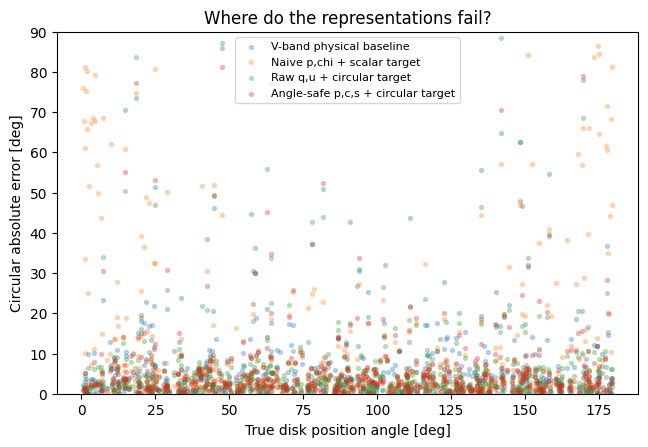

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.7))
for name, pred in predictions.items():
    err = orientation_error_deg(true_test, pred)
    ax.scatter(true_test, err, s=8, alpha=0.28, label=name)
ax.set_xlabel("True disk position angle [deg]")
ax.set_ylabel("Circular absolute error [deg]")
ax.set_title("Where do the representations fail?")
ax.set_ylim(0, 90)
ax.legend(fontsize=8)
plt.show()


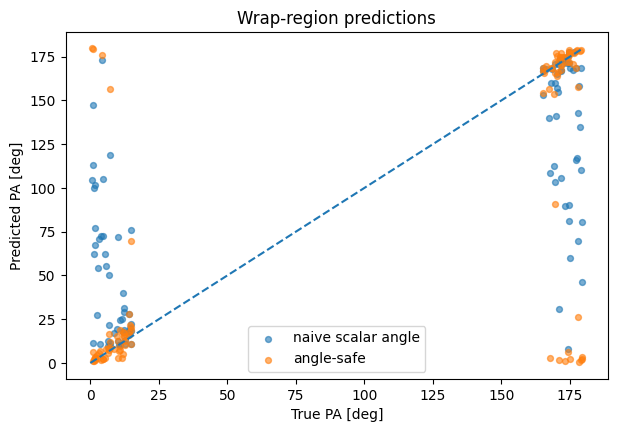

In [12]:
# A focused view of the wrap boundary.
fig, ax = plt.subplots(figsize=(7, 4.5))
m = wrap_mask
ax.scatter(true_test[m], pred_naive[m], s=18, alpha=0.6, label="naive scalar angle")
ax.scatter(true_test[m], pred_safe[m], s=18, alpha=0.6, label="angle-safe")
ax.plot([0, 180], [0, 180], linestyle="--")
ax.set_xlabel("True PA [deg]")
ax.set_ylabel("Predicted PA [deg]")
ax.set_title("Wrap-region predictions")
ax.legend()
plt.show()


## 7. Student intervention — choose one

Do not simply rerun the notebook.

Choose one scientific perturbation and state a hypothesis **before** executing it.

### A. Increase polarimetric noise

Double the measurement uncertainty.

Which representation degrades first?

### B. Increase interstellar polarization

Make the nuisance component comparable to the disk signal.

Does combining three bands still help?

### C. Remove one band

Retrain using only $V$, or only $B$ and $R$.

How much information was actually coming from multi-band structure?

### D. Focus on low-inclination systems

Restrict evaluation to small \(i\), where intrinsic polarization is weak.

Which estimator becomes unstable first?

### E. Compare input geometry only

Keep the circular target fixed and compare raw $(q,u)$ against
$(p,~\cos2\chi,~\sin2\chi)$.

Is one consistently better, or are they mostly equivalent once the target geometry is correct?

---

## Report back

Use exactly four statements:

1. **Hypothesis:** what did you expect?
2. **Intervention:** what did you change?
3. **Result:** what changed quantitatively?
4. **Interpretation:** what does the result imply physically or methodologically?


In [13]:
# Student intervention workspace.
#
# 1. Write your hypothesis in a Markdown cell first.
# 2. Implement ONE intervention A–E.
# 3. Recompute the relevant circular-error diagnostics.
# 4. Prepare a four-statement report-back.


# Slot 1 synthesis

The important result is broader than polarimetry:

$$
\boxed{
\text{physical symmetry}
\rightarrow
\text{representation geometry}
\rightarrow
\text{learning behavior}
}
$$

Examples encountered during the mini-course now include:

- class imbalance;
- spectral locality;
- irregular temporal sampling;
- angular periodicity.

A model does not receive “the astrophysical object.”

It receives **our computational representation of that object**.

That representation is already part of the scientific model.


# Slot 2 — Mini-project research studio

No new ML architecture is introduced in this slot.

The objective is to convert the techniques from the course into a **small defensible research design**.

Each group chooses one mini-project theme and produces:

1. a one-sentence scientific question;
2. a well-defined target/output;
3. a baseline;
4. a main model;
5. a validation protocol;
6. a primary metric;
7. one major confounder/failure mode;
8. one decisive figure or table;
9. one minimum viable experiment;
10. one optional extension.

---

# Available mini-project directions

### 1. Variable-star classification
Time-series classification; features vs learned representation.

### 2. Galaxy morphology
Image classification; classical/image baseline vs CNN.

### 3. Photometric redshift
Regression; uncertainty and domain shift.

### 4. Stellar parameter inference from spectra
Regression from spectral representations.

### 5. Exoplanet transit rare-event classification
Imbalance, recall/precision, threshold policy.

### 6. Astrophysical anomaly detection
Unsupervised/one-class representation and scientific validation.

### 7. Polarimetry and disk geometry
Stokes-space representations, periodic variables, uncertainty.

### 8. PINNs for stellar structure
Lane–Emden forward/inverse problem and physics-informed validation.

The project should be **small enough to finish**, but strong enough to support one clear scientific
claim.


# 8. Research canvas

Complete this **before coding**.

| Component | Group decision |
|---|---|
| Scientific question | ? |
| Unit of analysis | ? |
| Input data | ? |
| Target/output | ? |
| Representation(s) | ? |
| Simplest baseline | ? |
| Main model | ? |
| Train/validation/test strategy | ? |
| Primary metric | ? |
| Secondary diagnostic | ? |
| Main confounder | ? |
| Leakage risk | ? |
| Expected failure mode | ? |
| Decisive figure/table | ? |
| Reproducibility requirement | ? |

### Constraint

Your scientific question must be answerable by a result of the form:

> “Under **these data and validation conditions**, representation/model \(A\) does/does not improve
> **this scientifically relevant quantity** relative to baseline \(B\).”

Avoid questions of the form:

> “Can AI be used for X?”

That is usually too broad to test.


In [14]:
# Optional: create a one-row research-canvas table for your group.

research_canvas = pd.DataFrame([{
    "scientific_question": "",
    "unit_of_analysis": "",
    "input_data": "",
    "target_or_output": "",
    "representations": "",
    "baseline": "",
    "main_model": "",
    "split_strategy": "",
    "primary_metric": "",
    "secondary_diagnostic": "",
    "main_confounder": "",
    "leakage_risk": "",
    "expected_failure_mode": "",
    "decisive_figure_or_table": "",
    "reproducibility_requirement": "",
}])

research_canvas


,scientific_question,unit_of_analysis,input_data,target_or_output,representations,baseline,main_model,split_strategy,primary_metric,secondary_diagnostic,main_confounder,leakage_risk,expected_failure_mode,decisive_figure_or_table,reproducibility_requirement
0,,,,,,,,,,,,,,,


# 9. Design the Minimum Viable Experiment (MVE)

Before adding transformers, diffusion models, PINNs, or elaborate tuning, define the smallest experiment
that can falsify your idea.

A good MVE contains:

$$
\boxed{
\text{one split}
+
\text{one baseline}
+
\text{one main model}
+
\text{one metric}
+
\text{one diagnostic figure}
}
$$

### Example

For rare transit candidate classification:

- baseline: logistic regression on engineered features;
- main model: 1D CNN;
- primary metric: average precision;
- operational metric: recall at fixed precision;
- decisive figure: precision–recall curves on a frozen test set.

If the MVE does not work, that is already a scientific result.

---

## Group task

Write the sequence of your first five executable notebook cells.

They should be something like:

1. load/generate data;
2. audit target and provenance;
3. freeze splits;
4. train baseline;
5. evaluate baseline.

If your first five cells begin with a sophisticated neural network, reconsider the workflow.


In [15]:
# Minimum Viable Experiment plan

mve = {
    "split": "",
    "baseline": "",
    "main_model": "",
    "primary_metric": "",
    "diagnostic_figure": "",
    "first_five_notebook_cells": [
        "",
        "",
        "",
        "",
        "",
    ],
}

mve


{'split': '',
 'baseline': '',
 'main_model': '',
 'primary_metric': '',
 'diagnostic_figure': '',
 'first_five_notebook_cells': ['', '', '', '', '']}

# 10. Three-minute project pitch

Each group gets approximately **2–3 minutes**.

Use only this structure:

### 1. Scientific question — 20 s
What astrophysical question are you testing?

### 2. Data and representation — 30 s
What does one sample look like? What representation will the model receive?

### 3. Baseline and main model — 30 s
What is the simplest serious competitor?

### 4. Validation and metric — 30 s
How will you know whether the result generalizes?

### 5. Failure mode — 20 s
What could make an apparently good result scientifically misleading?

### 6. Decisive result — 20 s
What single plot or table would convince you?

### 7. Optional extension — only if time remains

Do **not** spend the pitch explaining neural-network architecture details unless they are central to the
scientific hypothesis.


# 11. Peer-review checkpoint

After each pitch, another group asks **one** question from this list:

- What is your baseline?
- Could there be leakage?
- Why is that metric scientifically appropriate?
- What nuisance variable could the model learn?
- Does your split reflect the intended deployment domain?
- Is the representation physically sensible?
- What result would falsify your hypothesis?
- What will you do if the complex model does not beat the baseline?

Then the presenting group revises **one line** of its research canvas.

This mirrors actual scientific practice:

$$
\boxed{
\text{proposal}
\rightarrow
\text{critique}
\rightarrow
\text{revision}
}
$$


# 12. End-of-course synthesis

Across the mini-course, the workflow has become progressively less model-centric.

### Lesson 0
$$
\text{mathematical/statistical/computational vocabulary}
$$

### Week 1
$$
\text{learning theory}
\rightarrow
\text{deep learning}
\rightarrow
\text{scientific reliability}
$$

### Monday laboratory
$$
\text{baseline}
\rightarrow
\text{classical ML}
\rightarrow
\text{MLP}
$$

### Wednesday laboratory
$$
\text{representation}
\rightarrow
\text{architecture}
$$

### Friday laboratory
$$
\text{physical geometry}
\rightarrow
\text{scientific decision}
\rightarrow
\text{research design}
$$

The final principle is:

$$
\boxed{
\text{Good astrophysical ML is not the search for the most complicated model.}
}
$$

It is the construction of a chain in which

$$
\boxed{
\text{question}
\rightarrow
\text{data}
\rightarrow
\text{representation}
\rightarrow
\text{model}
\rightarrow
\text{validation}
\rightarrow
\text{uncertainty}
\rightarrow
\text{scientific claim}
}
$$

remains defensible at every step.

### Final question to the class

> **What evidence would you need before trusting your mini-project model enough to make an
> astrophysical claim?**


---